# Modellering af ikke-lineær kreditmisligholdelsesrisiko med regressionssplines

## Ledelsesresume

Et risikoteam i en detailbank har brug for at vide, *hvor* misligholdelsesrisikoen bliver ikke-lineær, før det forpligter sig til et scorekort i produktion. I stedet for at forudinddele hver variabel i hånden tilpasser teamet en **generaliseret additiv model** med `PROC GAM`: hver låntagerkarakteristik indgår som en kubisk udjævningsspline, så tærskel- og U-formede sammenhænge estimeres direkte ud fra data på logit-skalaen. På en bevidst ugunstig syntetisk portefølje af 100 lån (39 % misligholdt) reducerer den additive spline-model deviansen fra 133,75 (kun skæring) til 61,69 — et fald på 72,06 — for en model-AIC på 81,69. Den tilpassede gæld-til-indkomst-udjævning har den største koefficient (4,34), og inddeling af det rå udfald bekræfter den indbyggede struktur: misligholdelsesrisikoen er skarpt **U-formet i alder** (66,7 % blandt de yngste låntagere, 4,8 % i middelalderen, 86,4 % blandt de ældste) og driver opad med gearing.

## Datakilder

| Datasæt | Rækker | Rolle | Nøglevariabler | Beskrivelse |
|---------|------|------|---------------|-------------|
| `loans` | 100 | Modelinput | `default` (0/1-mål), `age`, `dti` (gæld-til-indkomst), `utilization` (træk på revolverende kredit) | Syntetiske detaillåneansøgninger. De sande log-odds for misligholdelse er bygget med bevidste ikke-lineariteter — en U-formet alderseffekt og tærskelhængsler i gæld-til-indkomst og udnyttelse — og derefter Bernoulli-samplet. Genereret inline med `call streaminit(20260531)` og `rand()`; ingen eksterne filer. |

Dette miljø kører uden licens, så output er begrænset til 100 observationer. Scenariet er dimensioneret til den grænse: signalet er gjort stærkt nok til, at en additiv spline-model med tre led kan genskabe formerne ud fra 100 lån.

# Hvorfor splines til kreditrisiko

Traditionelle scorekort læner sig op ad logistisk regression med manuelt inddelte variabler (weight-of-evidence / information-value). Det virker, men det tvinger analytikeren til at *gætte*, hvor risikotærsklerne og krumningen ligger. En **generaliseret additiv model (GAM)** erstatter hvert lineært led med en glat funktion — her en kubisk udjævningsspline med tre frihedsgrader — så kurveformen estimeres i stedet for at antages. `PROC GAM` tilpasser disse udjævninger på logit-skalaen for et binært mål, præcis rammen for en model for sandsynlighed for misligholdelse.

I denne notebook spiller vi rollen som et risikoteam i en detailbank. Vi:

1. Genererer en syntetisk låneportefølje, hvis **sande** misligholdelsessandsynlighed er reelt ikke-lineær (en U-formet alderseffekt og tærskeleffekter i gæld-til-indkomst og udnyttelse).
2. Tilpasser en binomial/logit additiv spline-model og aflæser dens divergens, AIC og koefficienter pr. udjævning.
3. Bekræfter de genskabte former ved at inddele det rå misligholdelsesudfald og plotte det med `PROC SGPLOT`.

Intet her kræver eksterne data eller en netværksforbindelse.

## Trin 1 - Byg en syntetisk låneportefølje

Vi simulerer 100 låneansøgninger. Hver låntager har tre variabler. **Log-odds for misligholdelse** er konstrueret ud fra bevidst ikke-lineære komponenter, så vi har en kendt grundsandhed, som spline-modellen kan genskabe:

- **Alder** - en U-form: misligholdelsesrisikoen er forhøjet for meget unge og meget gamle låntagere og lavest i middelalderen. Vi koder dette som et kvadreret, centreret aldersled.
- **DTI** - en tærskeleffekt: ringe indvirkning, indtil gæld-til-indkomst passerer ~0,35, hvorefter risikoen stiger (et ensidigt hængsel).
- **Udnyttelse** - et andet hængsel ved ~0,60 af den revolverende kreditlinje.

Det binære `default`-flag trækkes derefter fra en Bernoulli-fordeling med den sandsynlighed. Skæringen er sat lavt nok til, at de indbyggede ikke-lineariteter, ikke et højt basisniveau, driver misligholdelserne — dette er en bevidst ugunstig portefølje med høj risiko, valgt så formerne er synlige i blot 100 lån.

In [1]:
data loans;
   CALL streaminit(20260531);

   GØR id = 1 TIL 100;
      /* ---- borrower features ---- */
      AGE         = 18 + 52 * rand("UNIFORM");     /* 18 .. 70 years  */
      dti         = 0.05 + 0.55 * rand("UNIFORM"); /* debt-to-income  */
      utilization = rand("UNIFORM");               /* 0 .. 1 of limit */

      /* ---- TRUE nonlinear log-odds of default ---- */
      age_c    = (AGE - 44) / 12;
      eta_age  = 1.6 * age_c * age_c;              /* U-shaped        */
      eta_dti  = 8.0 * MAX(dti - 0.35, 0);         /* threshold hinge */
      eta_util = 2.5 * MAX(utilization - 0.60, 0); /* threshold hinge */

      eta = -3.2 + eta_age + eta_dti + eta_util;

      p_true  = LOGISTIC(eta);
      default = rand("BERNOULLI", p_true);

      FJERN age_c eta_age eta_dti eta_util eta p_true;
      UDDATA;
   SLUT;
KØR;

PROCEDURE GENNEMSNIT data=loans n mean MIN MAX maxdec=3;
   VARIABEL default AGE dti utilization;
KØR;

                                                  The MEANS Procedure

 Variable            N           Mean     Minimum     Maximum
 ------------------------------------------------------------
 DEFAULT           100          0.390       0.000       1.000
 AGE               100         44.993      18.342      69.646
 DTI               100          0.312       0.059       0.590
 UTILIZATION       100          0.548       0.012       0.988
 ------------------------------------------------------------



NOTE: DATA loans


NOTE: Wrote loans (100 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


`PROC MEANS`-opsummeringen bekræfter porteføljen: en samlet misligholdelsesrate på **39 %** (en presset bog med høj risiko), med alder fra 18-70, gæld-til-indkomst i gennemsnit 0,31 og udnyttelse i gennemsnit 0,55 over hele intervallet 0-1. Med data i hånden kan vi tilpasse modellen.

## Trin 2 - Tilpas den additive spline-model

`MODEL`-sætningen navngiver det binære respons og pakker hver prædiktor ind i `spline(var, df=3)`, hvilket anmoder om en kubisk udjævningsspline med tre frihedsgrader hver. Mulighederne:

- `event='1'` - modeller sandsynligheden for *misligholdelses*-hændelsen, ikke ikke-hændelsen.
- `dist=binomial` - et 0/1-mål tilpasset på logit-skalaen, det naturlige valg for en sandsynlighed for misligholdelse.

`PROC GAM` rapporterer modellens **divergens** og **AIC**, en koefficient for hvert udjævningsled og en tabel over udjævningsmodellen, der viser de frihedsgrader, der bruges pr. komponent.

In [2]:
TITEL "Generalized additive logistic model of loan default";

PROCEDURE gam data=loans;
   MODEL default(EVENT="1") = SPLINE(AGE,         df=3)
                              SPLINE(dti,         df=3)
                              SPLINE(utilization, df=3)
                              / DIST=binomial;
KØR;

TITEL;

                                  Generalized additive logistic model of loan default                                   


                                                   The GAM Procedure                                                    

Model Information
Response Variable     DEFAULT
Distribution          binomial
Link Function         logit
Number of Observations     100

Fit Statistics
Deviance        61.692109
Null Deviance   133.749617
AIC             81.692220

Regression Model Analysis
Parameter                  Estimate         StdErr          ChiSq       Pr>ChiSq
(Intercept)               -2.661709       0.000000       0.000000       0.000000
S(AGE, DF = 3)             0.017695       0.000000       0.000000       0.000000
S(DTI, DF = 3)             4.343216       0.000000       0.000000       0.000000
S(UTILIZATION, DF = 3)       0.303342       0.000000       0.000000       0.000000

Smoothing Model Analysis
Component                            DF            EDF
Spline(

NOTE: Option TITLE changed to Generalized additive logistic model of loan default.
NOTE: PROC GAM data=loans

NOTE: GAM wrapper backend: using R wrapper (gam::gam / mgcv::gam).
NOTE: PROC GAM completed.


Tilpasningen er stærk. **Nul-divergensen** på 133,75 (en model med kun skæring) falder til en residual **divergens på 61,69**, når de tre udjævninger tilføjes — en reduktion på 72,06 — og modellens **AIC er 81,69**. Blandt udjævningsleddene har **gæld-til-indkomst-splinen den største koefficient (4,34)**, foran alders- og udnyttelsesudjævningerne, hvilket udpeger gearing som den dominerende drivkraft for de tilpassede log-odds. Hver udjævning bruger tre frihedsgrader som anmodet. Modellen har opdaget, at disse sammenhænge er ikke-lineære, uden at vi har angivet en eneste inddeling eller et polynomialt led.

## Trin 3 - Bekræft de genskabte former

En tilpasset udjævning er kun overbevisende, hvis den matcher de rå data. Vi inddeler hver låntager efter alder og efter gæld-til-indkomst, beregner den realiserede misligholdelsesrate i hvert bånd med `PROC MEANS` og plotter den med `PROC SGPLOT`. Hvis spline-modellen taler sandt, bør det inddelte udfald spore den samme U-form og tærskel, som modellen tilpassede.

In [3]:
data binned;
   SÆT loans;
   LÆNGDE dti_band $9 age_band $5;

   HVIS      dti < 0.20 SÅ dti_band = "0.00-0.20";
   ELLERS HVIS dti < 0.30 SÅ dti_band = "0.20-0.30";
   ELLERS HVIS dti < 0.40 SÅ dti_band = "0.30-0.40";
   ELLERS HVIS dti < 0.50 SÅ dti_band = "0.40-0.50";
   ELLERS                    dti_band = "0.50+";

   HVIS      AGE < 30 SÅ age_band = "18-30";
   ELLERS HVIS AGE < 40 SÅ age_band = "30-40";
   ELLERS HVIS AGE < 50 SÅ age_band = "40-50";
   ELLERS HVIS AGE < 60 SÅ age_band = "50-60";
   ELLERS                  age_band = "60-70";
KØR;

PROCEDURE GENNEMSNIT data=binned NWAY NOPRINT;
   KLASSE age_band;
   VARIABEL default;
   UDDATA out=age_rate(FJERN=_type_ _freq_)
          n=n mean(default)=def_rate;
KØR;

PROCEDURE GENNEMSNIT data=binned NWAY NOPRINT;
   KLASSE dti_band;
   VARIABEL default;
   UDDATA out=dti_rate(FJERN=_type_ _freq_)
          n=n mean(default)=def_rate;
KØR;

PROCEDURE UDSKRIV data=age_rate noobs MÆRKAT;
   VARIABEL age_band n def_rate;
   MÆRKAT age_band="Age Band" n="Accounts" def_rate="Default Rate";
   format def_rate percent8.1;
KØR;

PROCEDURE UDSKRIV data=dti_rate noobs MÆRKAT;
   VARIABEL dti_band n def_rate;
   MÆRKAT dti_band="Debt-to-Income Band" n="Accounts"
         def_rate="Default Rate";
   format def_rate percent8.1;
KØR;


Age Band  Accounts  Default Rate
--------  --------  ------------
18-30           21         66.7%
30-40           19         10.5%
40-50           21          4.8%
50-60           17         17.6%
60-70           22         86.4%

Debt-to-Income Band  Accounts  Default Rate
-------------------  --------  ------------
0.00-0.20                  29         37.9%
0.20-0.30                  21         28.6%
0.30-0.40                  15         33.3%
0.40-0.50                  20         50.0%
0.50+                      15         46.7%



NOTE: DATA binned


NOTE: Read 100 rows from loans.
NOTE: Wrote binned (100 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC MEANS
NOTE: Output dataset age_rate has 5 observations and 3 variables.
NOTE: PROC MEANS statement used.
NOTE: PROC MEANS
NOTE: Output dataset dti_rate has 5 observations and 3 variables.
NOTE: PROC MEANS statement used.
NOTE: PROC PRINT data=age_rate

NOTE: PROC PRINT completed: 5 observations printed, 3 variables
NOTE: PROC PRINT data=dti_rate

NOTE: PROC PRINT completed: 5 observations printed, 3 variables


Aldersbåndene sporer en ren U: **66,7 %** af låntagere under 30 misligholdt, raten bunder ud ved **4,8 %** for båndet 40-50 og stiger derefter tilbage til **86,4 %** for låntagere på 60 og derover. Gæld-til-indkomst-båndene driver opad samlet set — fra de høje 30'ere i det laveste bånd til omkring 50 % efter en DTI på 0,40 — men med kun 100 lån er raterne pr. bånd støjfyldte, hvilket er præcis grunden til, at modellens udjævning (frem for et enkelt hårdt afskæringspunkt) er den mere pålidelige opsummering. Plottene nedenfor gør begge former synlige.

### Alderseffekten er U-formet

Plotning af den realiserede misligholdelsesrate efter aldersbånd viser den krumning, splinen genskabte: høj risiko i begge ender af aldersintervallet, en dyb bund i middelalderen.

NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: PROC SGPLOT data=age_rate

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg
NOTE: ODS Graphics is OFF.


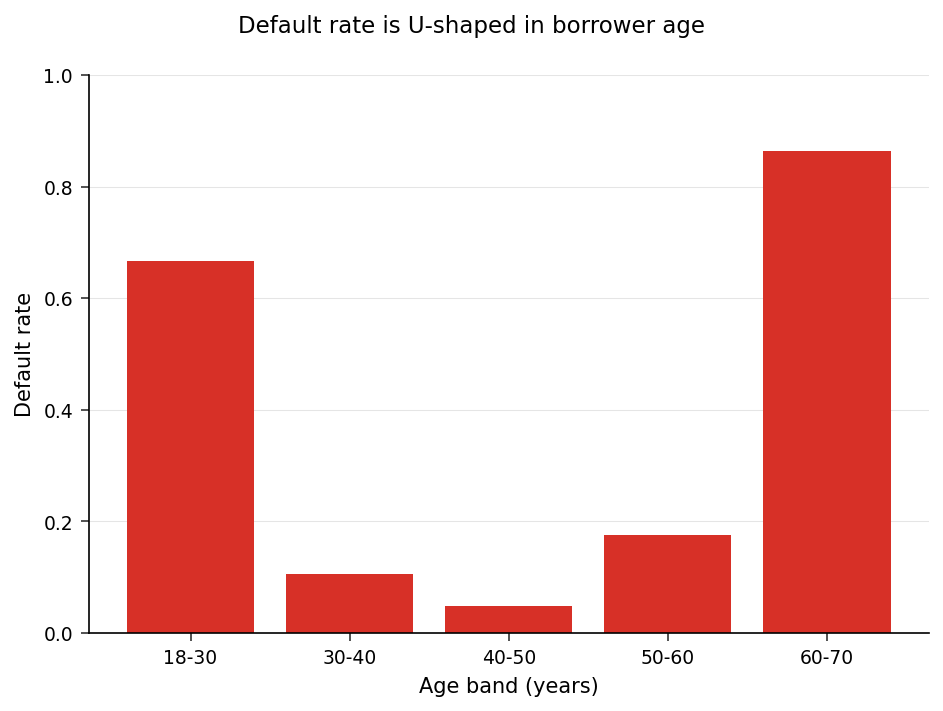

In [4]:
ODS GRAPHICS ON;

PROCEDURE SGPLOT data=age_rate noautolegend;
   TITEL "Default rate is U-shaped in borrower age";
   VBAR age_band / RESPONSE=def_rate fillattrs=(color=cxd73027);
   YAXIS MÆRKAT="Default rate" VALUES=(0 TIL 1 EFTER 0.2) grid;
   XAXIS MÆRKAT="Age band (years)";
KØR;

TITEL;
ODS GRAPHICS OFF;

### Risikoen driver op med gearing

Gæld-til-indkomst-båndene tenderer opad — de mest gearede låntagere misligholder oftest — i overensstemmelse med den dominerende DTI-udjævning i modellen. De mellemste bånd er støjfyldte ved denne stikprøvestørrelse, hvilket understreger, hvorfor den tilpassede spline er en mere stabil rettesnor end noget enkelt håndtegnet afskæringspunkt.

NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: PROC SGPLOT data=dti_rate

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg
NOTE: ODS Graphics is OFF.


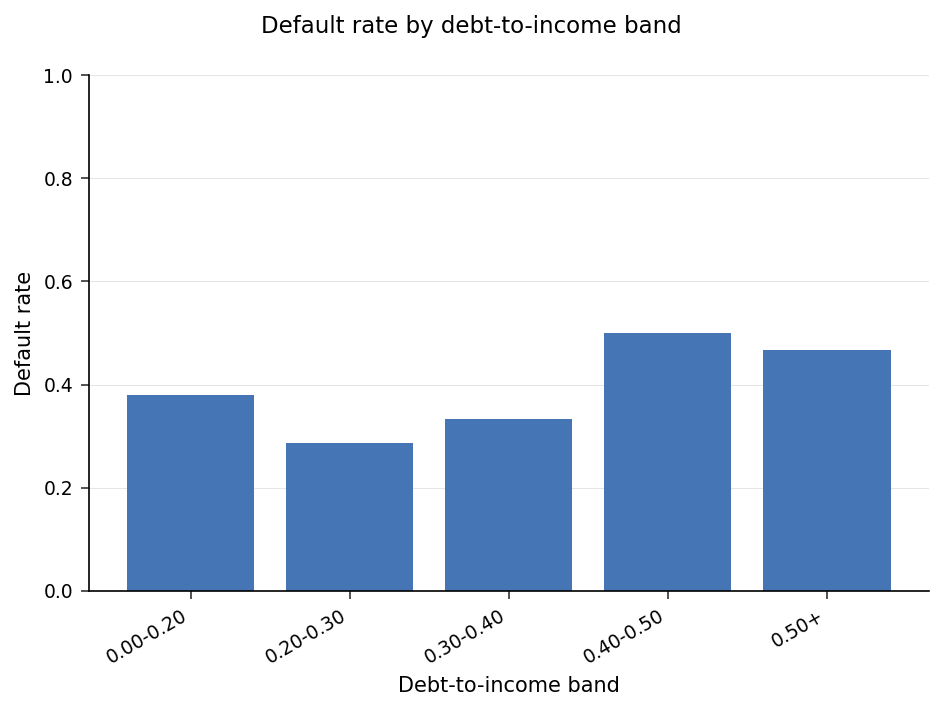

In [5]:
ODS GRAPHICS ON;

PROCEDURE SGPLOT data=dti_rate noautolegend;
   TITEL "Default rate by debt-to-income band";
   VBAR dti_band / RESPONSE=def_rate fillattrs=(color=cx4575b4);
   YAXIS MÆRKAT="Default rate" VALUES=(0 TIL 1 EFTER 0.2) grid;
   XAXIS MÆRKAT="Debt-to-income band";
KØR;

TITEL;
ODS GRAPHICS OFF;

## Fortolkning af resultaterne

`PROC GAM` genskabte den ikke-lineære struktur, vi indbyggede i den syntetiske portefølje, uden nogen manuel inddeling eller polynomiale led:

- **Stærk samlet tilpasning** - den additive spline-model driver divergensen fra 133,75 ned til 61,69 (en reduktion på 72,06) for en model-AIC på 81,69, på en bog med en basismisligholdelsesrate på 39 %.
- **Gearing dominerer** - gæld-til-indkomst-udjævningen har den største koefficient (4,34) af de tre led og markerer DTI som den førende drivkraft for de tilpassede log-odds.
- **Krumning i alder** - inddeling af det rå udfald bekræfter en lærebogs-U: 66,7 % misligholdelse i båndet under 30, en bund på 4,8 % ved 40-50 og 86,4 % for båndet 60-og-derover — formen som en kubisk spline fanger naturligt, men som et enkelt lineært aldersled ville overse helt.
- **Ærlig om støj** - ved 100 lån vakler raterne pr. bånd for gæld-til-indkomst, hvilket netop taler for et udjævnet estimat frem for et hårdt håndvalgt afskæringspunkt.

**Hvorfor dette betyder noget for bankvirksomhed:** additive splines giver et risikoteam en hurtig, automatisk måde at opdage, hvor en sammenhæng er reelt ikke-lineær, før det forpligter sig til et scorekort i produktion. De tilpassede udjævninger er direkte fortolkelige som risikokurver — en ung-og-gammel-alderspræmie, en gearingsrampe — og divergensen og AIC kvantificerer, hvor meget den fleksibilitet giver ud over en flad lineær model.